In [3]:
# ============================================================
# Setup: imports, paths, reproducibility, device
# ============================================================

import os
import random
import json
from pathlib import Path
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
import torchvision
from torchvision import transforms, datasets, models
import matplotlib.pyplot as plt
from PIL import Image

# --- Reproducibility ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
# Note: full determinism on GPU also needs torch.backends.cudnn.deterministic = True,
# but that slows training. We accept tiny non-determinism for speed.

# --- Device ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Mount Drive ---
from google.colab import drive
drive.mount('/content/drive')

# --- Project paths ---
PROJECT_ROOT = Path("/content/drive/MyDrive/comp8430_project")
DATA_DIR     = PROJECT_ROOT / "data" / "resized_256"
OUTPUT_DIR   = PROJECT_ROOT / "outputs"
FIG_DIR      = OUTPUT_DIR / "figures"
MODEL_DIR    = OUTPUT_DIR / "models"
LOG_DIR      = OUTPUT_DIR / "logs"

for d in [OUTPUT_DIR, FIG_DIR, MODEL_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# --- Sanity prints ---
print(f"PyTorch:       {torch.__version__}")
print(f"Torchvision:   {torchvision.__version__}")
print(f"Device:        {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU:           {torch.cuda.get_device_name(0)}")
    print(f"GPU memory:    {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"Project root:  {PROJECT_ROOT}  exists={PROJECT_ROOT.exists()}")
print(f"Data dir:      {DATA_DIR}      exists={DATA_DIR.exists()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PyTorch:       2.10.0+cu128
Torchvision:   0.25.0+cu128
Device:        cuda
GPU:           NVIDIA L4
GPU memory:    23.7 GB
Project root:  /content/drive/MyDrive/comp8430_project  exists=True
Data dir:      /content/drive/MyDrive/comp8430_project/data/resized_256      exists=True


In [4]:
# ============================================================
# Dataset inventory: list classes, count images, check formats
# ============================================================

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.webp'}
PROBLEM_EXTS = {'.heic', '.heif'}  # iPhone default; PIL can't read without extra lib

assert DATA_DIR.exists(), f"Data dir not found: {DATA_DIR}"

class_dirs = sorted([d for d in DATA_DIR.iterdir() if d.is_dir()])
assert len(class_dirs) > 0, f"No class subfolders found in {DATA_DIR}"

print(f"Found {len(class_dirs)} class folders:\n")

counts = {}
problem_files = []
for d in class_dirs:
    images = []
    for f in d.iterdir():
        if f.suffix.lower() in IMG_EXTS:
            images.append(f)
        elif f.suffix.lower() in PROBLEM_EXTS:
            problem_files.append(f)
    counts[d.name] = len(images)
    print(f"  {d.name:40s} {len(images):4d} images")

total = sum(counts.values())
print(f"\nTotal images:    {total}")
print(f"Min per class:   {min(counts.values())}")
print(f"Max per class:   {max(counts.values())}")
print(f"Mean per class:  {total / len(counts):.1f}")

if problem_files:
    print(f"\n[!] Found {len(problem_files)} HEIC/HEIF files (iPhone format). "
          f"These need conversion or pillow-heif installed. Sample: {problem_files[0].name}")

Found 5 class folders:

  monster__ultra_blue_hawaiian               91 images
  monster__ultra_fiesta                      84 images
  monster__ultra_strawberry_dreams          102 images
  monster__zero_sugar                        98 images
  monster__zero_ultra                       104 images

Total images:    479
Min per class:   84
Max per class:   104
Mean per class:  95.8


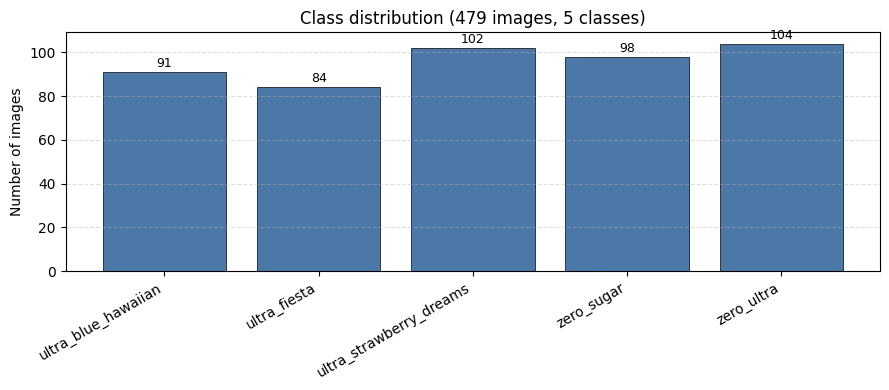

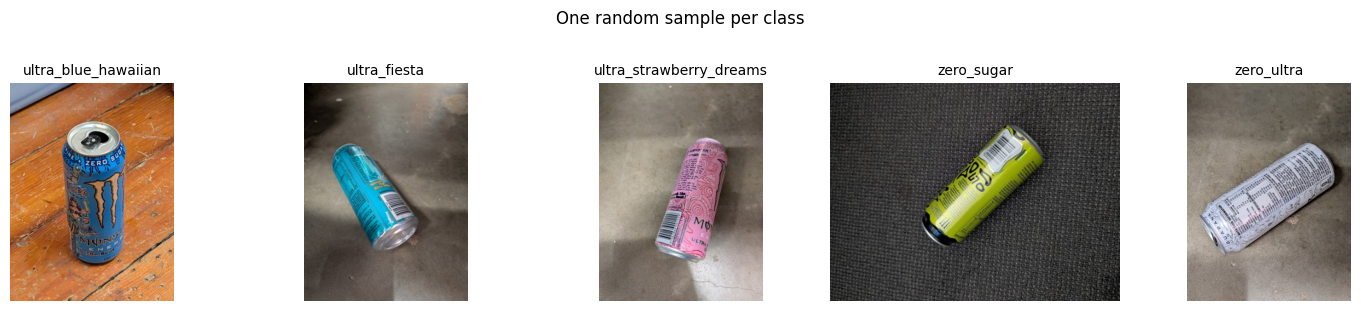


Saved figures to: /content/drive/MyDrive/comp8430_project/outputs/figures


In [5]:
# ============================================================
# Visual illustration of the dataset:
#   (1) class distribution bar chart
#   (2) sample grid (one image per class)
# Both figures are saved to outputs/figures/ for the report.
# ============================================================

import matplotlib.pyplot as plt
from PIL import Image

# ----- (1) Class distribution -----
# Re-count from the (resized) dataset so the figure reflects what training will actually see.
class_names = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
counts = {}
for name in class_names:
    counts[name] = sum(1 for f in (DATA_DIR / name).iterdir()
                       if f.suffix.lower() in IMG_EXTS)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(range(len(class_names)), [counts[n] for n in class_names],
              color="#4C78A8", edgecolor="black", linewidth=0.5)
ax.set_xticks(range(len(class_names)))
# shorten labels for display: drop the "monster__" prefix
short_labels = [n.replace("monster__", "") for n in class_names]
ax.set_xticklabels(short_labels, rotation=30, ha="right")
ax.set_ylabel("Number of images")
ax.set_title(f"Class distribution ({sum(counts.values())} images, {len(class_names)} classes)")
ax.grid(axis="y", linestyle="--", alpha=0.4)
# annotate each bar with its count
for bar, n in zip(bars, [counts[c] for c in class_names]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            str(n), ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# ----- (2) Sample grid: one random image per class -----
import random as _r
_r.seed(SEED)  # reproducible sample choice

n = len(class_names)
ncols = min(n, 5)
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 3 * nrows))
axes = axes.flatten() if n > 1 else [axes]

for ax, cname in zip(axes, class_names):
    files = [f for f in (DATA_DIR / cname).iterdir() if f.suffix.lower() in IMG_EXTS]
    img_path = _r.choice(files)
    img = Image.open(img_path).convert("RGB")
    ax.imshow(img)
    ax.set_title(cname.replace("monster__", ""), fontsize=10)
    ax.axis("off")

# hide any unused axes
for ax in axes[len(class_names):]:
    ax.axis("off")

plt.suptitle("One random sample per class", y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / "sample_grid.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nSaved figures to: {FIG_DIR}")

In [6]:
# ============================================================
# Stratified 60/10/30 train/val/test split.
# Output: outputs/logs/splits.json mapping each image path to
# its split. Used by BOTH models so comparisons are fair.
# ============================================================

import json
from collections import defaultdict

SPLITS_FILE = LOG_DIR / "splits.json"
TRAIN_FRAC, VAL_FRAC, TEST_FRAC = 0.60, 0.10, 0.30
assert abs(TRAIN_FRAC + VAL_FRAC + TEST_FRAC - 1.0) < 1e-9

# Gather (path, class_name) pairs grouped by class
by_class: dict[str, list[str]] = defaultdict(list)
for cdir in sorted([d for d in DATA_DIR.iterdir() if d.is_dir()]):
    for f in sorted(cdir.iterdir()):
        if f.suffix.lower() in IMG_EXTS:
            # Store path relative to DATA_DIR so splits.json stays portable
            rel = f.relative_to(DATA_DIR).as_posix()
            by_class[cdir.name].append(rel)

# Per-class stratified shuffle and slice, using a fresh local RNG so this
# cell is reproducible independently of any earlier random state.
rng = random.Random(SEED)

splits = {"train": [], "val": [], "test": []}
split_summary = {}

for cname, files in by_class.items():
    files = files.copy()
    rng.shuffle(files)
    n = len(files)
    n_train = int(round(n * TRAIN_FRAC))
    n_val   = int(round(n * VAL_FRAC))
    n_test  = n - n_train - n_val   # absorbs rounding so totals always match
    splits["train"].extend((f, cname) for f in files[:n_train])
    splits["val"].extend((f, cname)   for f in files[n_train:n_train + n_val])
    splits["test"].extend((f, cname)  for f in files[n_train + n_val:])
    split_summary[cname] = {"total": n, "train": n_train, "val": n_val, "test": n_test}

# Persist to JSON for reuse by training cells (and Phase 2/3 later)
with open(SPLITS_FILE, "w") as f:
    json.dump({
        "seed": SEED,
        "fractions": {"train": TRAIN_FRAC, "val": VAL_FRAC, "test": TEST_FRAC},
        "data_dir": str(DATA_DIR),
        "splits": {k: [list(t) for t in v] for k, v in splits.items()},
    }, f, indent=2)

# Pretty-print the per-class breakdown
print(f"{'class':<35s} {'total':>6s} {'train':>6s} {'val':>5s} {'test':>5s}")
print("-" * 60)
for cname, s in split_summary.items():
    print(f"{cname:<35s} {s['total']:>6d} {s['train']:>6d} {s['val']:>5d} {s['test']:>5d}")
print("-" * 60)
totals = {k: sum(s[k] for s in split_summary.values()) for k in ["total", "train", "val", "test"]}
print(f"{'TOTAL':<35s} {totals['total']:>6d} {totals['train']:>6d} {totals['val']:>5d} {totals['test']:>5d}")
print(f"\nSplit file saved: {SPLITS_FILE}")

class                                total  train   val  test
------------------------------------------------------------
monster__ultra_blue_hawaiian            91     55     9    27
monster__ultra_fiesta                   84     50     8    26
monster__ultra_strawberry_dreams       102     61    10    31
monster__zero_sugar                     98     59    10    29
monster__zero_ultra                    104     62    10    32
------------------------------------------------------------
TOTAL                                  479    287    47   145

Split file saved: /content/drive/MyDrive/comp8430_project/outputs/logs/splits.json


In [7]:
# ============================================================
# Transforms, Dataset class, and DataLoaders.
# - Train transform: light augmentation suited to canned objects.
# - Eval transform:  resize + center crop, no randomness.
# - Both use ImageNet mean/std (the pretrained models were
#   trained with this normalisation, so test-time inputs must match).
# ============================================================

from torch.utils.data import Dataset, DataLoader

# ImageNet normalisation stats (NEVER change these for ImageNet-pretrained models)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

IMG_SIZE = 224   # ResNet-50 and VGG-16 both expect 224x224

# --- Training transform: deliberately MODEST augmentation ---
# Why modest: fine-grained classification depends on small details.
# Heavy colour jitter or strong rotations can destroy the cues that
# distinguish e.g. zero_ultra from zero_sugar.
train_tf = transforms.Compose([
    transforms.Resize(256),                       # shorter side -> 256 (already true on disk, but safe)
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),   # mild zoom/translate
    transforms.RandomHorizontalFlip(p=0.5),                     # cans are roughly symmetric; flip is OK
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# --- Evaluation transform: deterministic, no randomness ---
eval_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# --- Dataset class that reads from splits.json ---
class CansDataset(Dataset):
    """Loads images according to the split file.

    Args:
        data_dir: root directory containing class subfolders.
        split_entries: list of (relative_path, class_name) tuples for this split.
        class_to_idx: mapping from class name to integer label.
        transform: torchvision transform pipeline to apply.
    """
    def __init__(self, data_dir, split_entries, class_to_idx, transform):
        self.data_dir = Path(data_dir)
        self.entries = split_entries
        self.class_to_idx = class_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.entries)

    def __getitem__(self, idx):
        rel_path, cname = self.entries[idx]
        img = Image.open(self.data_dir / rel_path).convert("RGB")
        img = self.transform(img)
        label = self.class_to_idx[cname]
        return img, label

# --- Load the splits file and build class index ---
with open(SPLITS_FILE) as f:
    split_doc = json.load(f)

# Class names sorted alphabetically -> indices 0..N-1.
# We sort so the mapping is stable across runs and notebooks.
CLASS_NAMES  = sorted(by_class.keys())
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}
IDX_TO_CLASS = {i: c for c, i in CLASS_TO_IDX.items()}
NUM_CLASSES  = len(CLASS_NAMES)

# --- Build datasets ---
train_ds = CansDataset(DATA_DIR, split_doc["splits"]["train"], CLASS_TO_IDX, train_tf)
val_ds   = CansDataset(DATA_DIR, split_doc["splits"]["val"],   CLASS_TO_IDX, eval_tf)
test_ds  = CansDataset(DATA_DIR, split_doc["splits"]["test"],  CLASS_TO_IDX, eval_tf)

# --- DataLoaders ---
BATCH_SIZE = 32      # Comfortable for both ResNet-50 and VGG-16 on an L4
NUM_WORKERS = 2      # Colab gives 2 vCPUs

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f"Classes ({NUM_CLASSES}): {CLASS_NAMES}")
print(f"Train: {len(train_ds):4d}  ({len(train_loader)} batches)")
print(f"Val:   {len(val_ds):4d}  ({len(val_loader)} batches)")
print(f"Test:  {len(test_ds):4d}  ({len(test_loader)} batches)")

# --- Sanity check: pull one batch and verify shapes ---
imgs, labels = next(iter(train_loader))
print(f"\nOne train batch:")
print(f"  images: {tuple(imgs.shape)}  dtype={imgs.dtype}  range=[{imgs.min():.2f}, {imgs.max():.2f}]")
print(f"  labels: {tuple(labels.shape)}  values={labels[:8].tolist()} ...")

Classes (5): ['monster__ultra_blue_hawaiian', 'monster__ultra_fiesta', 'monster__ultra_strawberry_dreams', 'monster__zero_sugar', 'monster__zero_ultra']
Train:  287  (9 batches)
Val:     47  (2 batches)
Test:   145  (5 batches)

One train batch:
  images: (32, 3, 224, 224)  dtype=torch.float32  range=[-2.12, 2.64]
  labels: (32,)  values=[3, 3, 0, 4, 3, 4, 2, 4] ...


In [8]:
# ============================================================
# Model factory: build a pretrained CNN with the classifier head
# swapped for our NUM_CLASSES output. Same interface for both
# architectures so training/eval code is shared.
#
# Two strategies are supported:
#   "feature_extractor": backbone frozen, only the new head trains.
#   "fine_tune":         everything trainable (lower LR usually wanted).
#
# For Phase 1-2 we start with feature_extractor: it's the standard
# transfer-learning baseline, fast to train, and a fair starting
# point for comparing two architectures.
# ============================================================

from torchvision.models import (
    resnet50, ResNet50_Weights,
    vgg16,    VGG16_Weights,
)

def build_model(name: str, num_classes: int, strategy: str = "feature_extractor"):
    """Return (model, params_to_optimize, info_dict)."""
    name = name.lower()

    if name == "resnet50":
        weights = ResNet50_Weights.IMAGENET1K_V2  # the better of the two official sets
        model = resnet50(weights=weights)
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)
        head_params = model.fc.parameters()

    elif name == "vgg16":
        weights = VGG16_Weights.IMAGENET1K_V1
        model = vgg16(weights=weights)
        # VGG's classifier is a Sequential of 6 layers ending in a 1000-way Linear.
        # We replace only the final layer to keep the rest of the classifier intact.
        in_features = model.classifier[-1].in_features
        model.classifier[-1] = nn.Linear(in_features, num_classes)
        head_params = model.classifier[-1].parameters()

    else:
        raise ValueError(f"Unknown model: {name}")

    if strategy == "feature_extractor":
        # Freeze everything, then unfreeze just the new head.
        for p in model.parameters():
            p.requires_grad = False
        for p in head_params:
            p.requires_grad = True
        params_to_optimize = [p for p in model.parameters() if p.requires_grad]
    elif strategy == "fine_tune":
        for p in model.parameters():
            p.requires_grad = True
        params_to_optimize = model.parameters()
    else:
        raise ValueError(f"Unknown strategy: {strategy}")

    n_total = sum(p.numel() for p in model.parameters())
    n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    info = {
        "name": name,
        "strategy": strategy,
        "weights": str(weights),
        "params_total": n_total,
        "params_trainable": n_trainable,
        "trainable_fraction": n_trainable / n_total,
    }
    return model.to(DEVICE), params_to_optimize, info

# --- Build both models once to verify and print sizes ---
for name in ["resnet50", "vgg16"]:
    m, _, info = build_model(name, NUM_CLASSES, strategy="feature_extractor")
    print(f"{info['name']:>10s}: total={info['params_total']/1e6:7.2f}M  "
          f"trainable={info['params_trainable']/1e6:6.3f}M  "
          f"({info['trainable_fraction']*100:5.2f}%)")
    del m
torch.cuda.empty_cache()

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 243MB/s]


  resnet50: total=  23.52M  trainable= 0.010M  ( 0.04%)
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 240MB/s]


     vgg16: total= 134.28M  trainable= 0.020M  ( 0.02%)


In [9]:
# ============================================================
# Training utilities:
#   - train_one_epoch: one pass over the training set, returns (loss, acc)
#   - evaluate:        deterministic pass over any loader, returns (loss, acc)
#   - train_model:     full training loop with per-epoch logging and
#                      best-checkpoint saving (by val accuracy)
# ============================================================

import time
from copy import deepcopy

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for imgs, labels in loader:
        imgs = imgs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += imgs.size(0)
    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    for imgs, labels in loader:
        imgs = imgs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        logits = model(imgs)
        loss = criterion(logits, labels)

        running_loss += loss.item() * imgs.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += imgs.size(0)
    return running_loss / total, correct / total


def train_model(model_name, num_epochs=10, lr=1e-3, weight_decay=1e-4, verbose=True):
    """Build, train, and return the model that performed best on the val set.

    Returns:
        best_model: the model with weights restored to the best-val epoch.
        history:    dict of per-epoch metrics for plotting.
        info:       model info dict from build_model.
    """
    model, params_to_optimize, info = build_model(model_name, NUM_CLASSES,
                                                  strategy="feature_extractor")
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(params_to_optimize, lr=lr, weight_decay=weight_decay)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_acc = -1.0
    best_state = None
    best_epoch = -1

    if verbose:
        print(f"\n=== Training {model_name} | feature_extractor | "
              f"lr={lr} wd={weight_decay} epochs={num_epochs} ===")
        print(f"{'Epoch':>5s} {'Train loss':>11s} {'Train acc':>10s} "
              f"{'Val loss':>9s} {'Val acc':>8s} {'Time':>7s}")

    for epoch in range(1, num_epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        va_loss, va_acc = evaluate(model, val_loader, criterion)
        dt = time.time() - t0

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        if va_acc > best_val_acc:
            best_val_acc = va_acc
            best_state = deepcopy(model.state_dict())
            best_epoch = epoch
            tag = " *"
        else:
            tag = ""

        if verbose:
            print(f"{epoch:5d} {tr_loss:11.4f} {tr_acc:10.4f} "
                  f"{va_loss:9.4f} {va_acc:8.4f} {dt:6.1f}s{tag}")

    # Restore best-on-val weights
    model.load_state_dict(best_state)
    if verbose:
        print(f"\nBest val acc: {best_val_acc:.4f} at epoch {best_epoch}")

    # Persist checkpoint to Drive so we don't have to re-train if the session resets
    ckpt_path = MODEL_DIR / f"{model_name}_phase1_2.pt"
    torch.save({
        "model_name": model_name,
        "state_dict": best_state,
        "class_to_idx": CLASS_TO_IDX,
        "best_val_acc": best_val_acc,
        "best_epoch": best_epoch,
        "history": history,
        "info": info,
    }, ckpt_path)
    if verbose:
        print(f"Saved: {ckpt_path}")

    return model, history, info

In [10]:
# ============================================================
# Train both models with identical hyperparameters and data.
# Storing results in a dict so all downstream analysis is symmetric.
# ============================================================

EPOCHS = 10
LR     = 1e-3
WD     = 1e-4

results = {}   # results[model_name] = {"model": ..., "history": ..., "info": ...}

for name in ["resnet50", "vgg16"]:
    model, history, info = train_model(name, num_epochs=EPOCHS, lr=LR, weight_decay=WD)
    results[name] = {"model": model, "history": history, "info": info}

# --- Summary table ---
print("\n" + "=" * 72)
print(f"{'Model':<12s} {'Best val acc':>14s} {'Best epoch':>12s} {'Trainable':>14s}")
print("-" * 72)
for name, r in results.items():
    h = r["history"]
    best = max(h["val_acc"])
    best_ep = h["val_acc"].index(best) + 1
    trainable_m = r["info"]["params_trainable"] / 1e6
    print(f"{name:<12s} {best:>14.4f} {best_ep:>12d} {trainable_m:>11.3f}M")
print("=" * 72)


=== Training resnet50 | feature_extractor | lr=0.001 wd=0.0001 epochs=10 ===
Epoch  Train loss  Train acc  Val loss  Val acc    Time
    1      1.5232     0.3589    1.3758   0.6383   82.0s *
    2      1.2751     0.7700    1.1804   0.8085    2.0s *
    3      1.1137     0.8188    1.0416   0.7872    2.0s
    4      0.9605     0.8502    0.9224   0.8511    2.1s *
    5      0.8481     0.8815    0.8312   0.8723    2.1s *
    6      0.7385     0.9129    0.7440   0.8936    2.1s *
    7      0.6639     0.8920    0.6666   0.9149    2.2s *
    8      0.6071     0.9373    0.6225   0.9149    2.0s
    9      0.5349     0.9408    0.5824   0.9149    2.1s
   10      0.5135     0.9303    0.5380   0.8936    2.1s

Best val acc: 0.9149 at epoch 7
Saved: /content/drive/MyDrive/comp8430_project/outputs/models/resnet50_phase1_2.pt

=== Training vgg16 | feature_extractor | lr=0.001 wd=0.0001 epochs=10 ===
Epoch  Train loss  Train acc  Val loss  Val acc    Time
    1      1.4789     0.3589    1.1205   0.5957

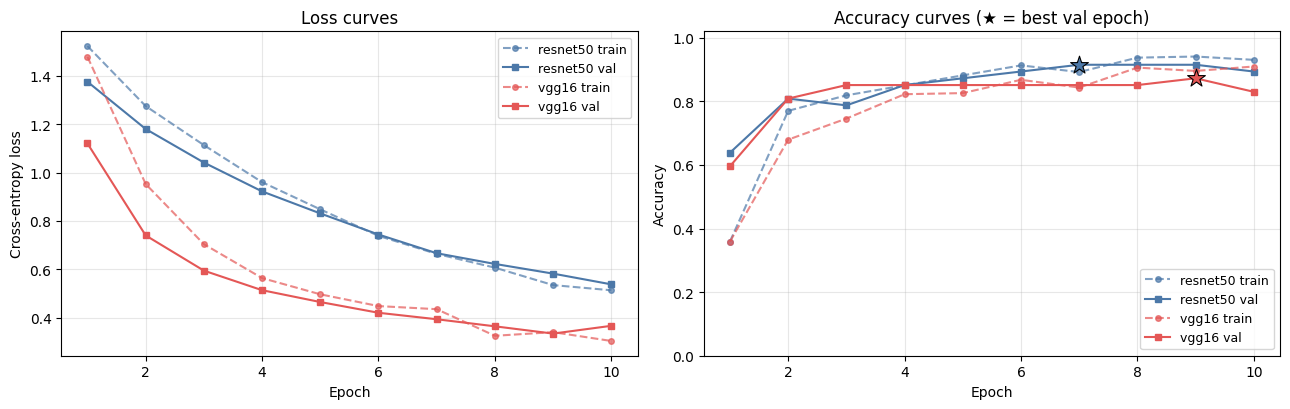


Saved: /content/drive/MyDrive/comp8430_project/outputs/figures/training_curves.png


In [11]:
# ============================================================
# Training-curve plots: loss and accuracy per epoch for both
# models, side by side. Saved to outputs/figures/.
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

colors = {"resnet50": "#4C78A8", "vgg16": "#E45756"}

# --- Loss plot ---
ax = axes[0]
for name, r in results.items():
    h = r["history"]
    epochs = range(1, len(h["train_loss"]) + 1)
    ax.plot(epochs, h["train_loss"], color=colors[name], linestyle="--",
            marker="o", markersize=4, label=f"{name} train", alpha=0.7)
    ax.plot(epochs, h["val_loss"],   color=colors[name], linestyle="-",
            marker="s", markersize=4, label=f"{name} val")
ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-entropy loss")
ax.set_title("Loss curves")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)

# --- Accuracy plot ---
ax = axes[1]
for name, r in results.items():
    h = r["history"]
    epochs = range(1, len(h["train_acc"]) + 1)
    ax.plot(epochs, h["train_acc"], color=colors[name], linestyle="--",
            marker="o", markersize=4, label=f"{name} train", alpha=0.7)
    ax.plot(epochs, h["val_acc"],   color=colors[name], linestyle="-",
            marker="s", markersize=4, label=f"{name} val")
    # mark the best-val epoch with a star
    best_ep = h["val_acc"].index(max(h["val_acc"])) + 1
    ax.scatter([best_ep], [max(h["val_acc"])], marker="*", s=180,
               color=colors[name], edgecolor="black", linewidth=0.8, zorder=5)
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy curves (★ = best val epoch)")
ax.set_ylim(0.0, 1.02)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9, loc="lower right")

plt.tight_layout()
plt.savefig(FIG_DIR / "training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nSaved: {FIG_DIR / 'training_curves.png'}")

In [12]:
# ============================================================
# Test-set evaluation: get final accuracy, per-class accuracy,
# predictions, and probability distributions for each model.
# Persist everything so downstream analysis cells can reload
# without re-running inference.
# ============================================================

import numpy as np
import torch.nn.functional as F

@torch.no_grad()
def predict_all(model, loader):
    """Run the model over a loader. Returns (labels, preds, probs, indices)
    where indices is the position in `loader.dataset.entries` for each row."""
    model.eval()
    all_labels, all_preds, all_probs = [], [], []
    for imgs, labels in loader:
        imgs = imgs.to(DEVICE, non_blocking=True)
        logits = model(imgs)
        probs = F.softmax(logits, dim=1)
        preds = logits.argmax(dim=1)
        all_labels.append(labels.cpu().numpy())
        all_preds.append(preds.cpu().numpy())
        all_probs.append(probs.cpu().numpy())
    return (np.concatenate(all_labels),
            np.concatenate(all_preds),
            np.concatenate(all_probs))

test_results = {}
print(f"{'Model':<12s} {'Test acc':>10s} {'Test loss':>11s} {'Correct':>10s}")
print("-" * 50)
for name, r in results.items():
    labels, preds, probs = predict_all(r["model"], test_loader)
    acc = (labels == preds).mean()
    # Cross-entropy loss on test set
    test_loss = -np.log(np.clip(probs[np.arange(len(labels)), labels], 1e-12, 1.0)).mean()
    test_results[name] = {"labels": labels, "preds": preds, "probs": probs,
                          "acc": acc, "loss": test_loss}
    print(f"{name:<12s} {acc:>10.4f} {test_loss:>11.4f} {(labels==preds).sum():>6d}/{len(labels):d}")

# --- Per-class accuracy ---
print("\nPer-class test accuracy:")
print(f"{'class':<35s} " + " ".join(f"{n:>10s}" for n in test_results.keys()))
print("-" * 60)
for ci, cname in enumerate(CLASS_NAMES):
    row = f"{cname:<35s} "
    for name, tr in test_results.items():
        mask = tr["labels"] == ci
        n_class = mask.sum()
        if n_class == 0:
            row += f"{'n/a':>10s} "
        else:
            cls_acc = (tr["preds"][mask] == ci).sum() / n_class
            row += f"{cls_acc:>10.4f} "
    print(row.rstrip())

Model          Test acc   Test loss    Correct
--------------------------------------------------
resnet50         0.8621      0.6880    125/145
vgg16            0.8345      0.3929    121/145

Per-class test accuracy:
class                                 resnet50      vgg16
------------------------------------------------------------
monster__ultra_blue_hawaiian            0.7778     0.8519
monster__ultra_fiesta                   0.6923     0.6154
monster__ultra_strawberry_dreams        0.9677     0.8387
monster__zero_sugar                     0.9310     0.9310
monster__zero_ultra                     0.9062     0.9062


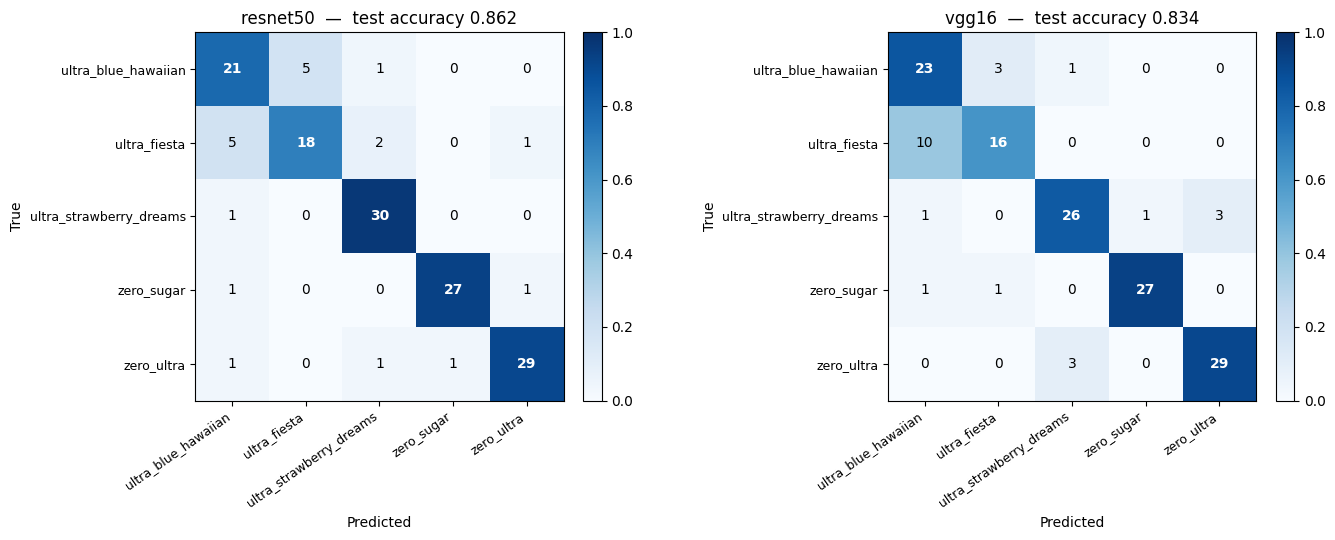


=== Confusion matrix — resnet50 ===
true \ pred                        ultra_blue_hawaiian  ultra_fiestaultra_strawberry_dreams    zero_sugar    zero_ultra
ultra_blue_hawaiian                            21             5             1             0             0
ultra_fiesta                                    5            18             2             0             1
ultra_strawberry_dreams                         1             0            30             0             0
zero_sugar                                      1             0             0            27             1
zero_ultra                                      1             0             1             1            29

=== Confusion matrix — vgg16 ===
true \ pred                        ultra_blue_hawaiian  ultra_fiestaultra_strawberry_dreams    zero_sugar    zero_ultra
ultra_blue_hawaiian                            23             3             1             0             0
ultra_fiesta                                   10    

In [13]:
# ============================================================
# Confusion matrices for both models, side by side.
# Rows = true class, columns = predicted class.
# Numbers are absolute counts; cell colour is row-normalised
# so per-class accuracy patterns pop visually.
# ============================================================

def confusion_matrix(labels, preds, num_classes):
    cm = np.zeros((num_classes, num_classes), dtype=int)
    for t, p in zip(labels, preds):
        cm[t, p] += 1
    return cm

short_names = [c.replace("monster__", "") for c in CLASS_NAMES]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, (name, tr) in zip(axes, test_results.items()):
    cm = confusion_matrix(tr["labels"], tr["preds"], NUM_CLASSES)
    cm_norm = cm / cm.sum(axis=1, keepdims=True)  # row-normalised for colour

    im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(NUM_CLASSES))
    ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(short_names, rotation=35, ha="right", fontsize=9)
    ax.set_yticklabels(short_names, fontsize=9)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"{name}  —  test accuracy {tr['acc']:.3f}")

    # Annotate cells with counts; colour the text for legibility
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            count = cm[i, j]
            txt_color = "white" if cm_norm[i, j] > 0.5 else "black"
            ax.text(j, i, str(count), ha="center", va="center",
                    color=txt_color, fontsize=10,
                    fontweight="bold" if i == j else "normal")

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig(FIG_DIR / "confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Print confusion matrices as text too (useful in the report and easier to copy) ---
for name, tr in test_results.items():
    cm = confusion_matrix(tr["labels"], tr["preds"], NUM_CLASSES)
    print(f"\n=== Confusion matrix — {name} ===")
    print(f"{'true \\ pred':<35s}" + "".join(f"{n:>14s}" for n in short_names))
    for i, cname in enumerate(short_names):
        row = f"{cname:<35s}" + "".join(f"{cm[i, j]:>14d}" for j in range(NUM_CLASSES))
        print(row)

In [14]:
# ============================================================
# Misclassification grid: show a sample of wrongly-classified
# test images with their true and predicted labels, sorted by
# confidence in the wrong answer (highest first = "most
# confidently wrong" examples are the most informative).
# ============================================================

def misclassified_grid(model_name, n=12):
    tr = test_results[model_name]
    labels = tr["labels"]
    preds  = tr["preds"]
    probs  = tr["probs"]

    wrong_idx = np.where(labels != preds)[0]
    if len(wrong_idx) == 0:
        print(f"{model_name}: no misclassifications.")
        return

    # Confidence in the (wrong) predicted class
    pred_conf = probs[wrong_idx, preds[wrong_idx]]
    # Sort wrongs by confidence-of-wrong-prediction, descending
    order = np.argsort(-pred_conf)
    wrong_idx = wrong_idx[order]
    pred_conf = pred_conf[order]

    n = min(n, len(wrong_idx))
    ncols = 4
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.3 * ncols, 3.3 * nrows))
    axes = np.array(axes).flatten()

    test_entries = split_doc["splits"]["test"]   # list of [rel_path, class_name]

    for ax, idx in zip(axes, wrong_idx[:n]):
        rel_path, true_cname = test_entries[idx]
        img = Image.open(DATA_DIR / rel_path).convert("RGB")
        ax.imshow(img)
        true_short = true_cname.replace("monster__", "")
        pred_short = IDX_TO_CLASS[preds[idx]].replace("monster__", "")
        conf = probs[idx, preds[idx]]
        ax.set_title(f"true: {true_short}\npred: {pred_short}  ({conf:.2f})",
                     fontsize=9, color="firebrick")
        ax.axis("off")
    for ax in axes[n:]:
        ax.axis("off")

    plt.suptitle(f"{model_name}: {n} most confidently wrong predictions (of {len(wrong_idx)})",
                 fontsize=11, y=1.00)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"misclassified_{model_name}.png", dpi=150, bbox_inches="tight")
    plt.show()

for name in ["resnet50", "vgg16"]:
    misclassified_grid(name, n=12)

Output hidden; open in https://colab.research.google.com to view.

In [15]:
# ============================================================
# Per-class precision, recall, F1, and support for both models.
# Implemented directly (no sklearn dependency) so the metric
# definitions are visible and defensible.
#
# For each class c (computed from the confusion matrix):
#   precision_c = TP_c / (TP_c + FP_c)   # of predictions for c, how many right?
#   recall_c    = TP_c / (TP_c + FN_c)   # of true c's, how many recovered?
#   f1_c        = 2 * P * R / (P + R)
#   support_c   = number of true examples in test set
#
# Aggregates:
#   accuracy        = total correct / total
#   macro F1        = mean of per-class F1     (treats every class equally)
#   weighted F1     = sum_c (support_c / N) * F1_c   (size-weighted)
# ============================================================

def classification_report_text(labels, preds, class_names):
    n = len(class_names)
    cm = np.zeros((n, n), dtype=int)
    for t, p in zip(labels, preds):
        cm[t, p] += 1

    tp = np.diag(cm)
    fp = cm.sum(axis=0) - tp
    fn = cm.sum(axis=1) - tp
    support = cm.sum(axis=1)

    precision = np.where(tp + fp > 0, tp / np.maximum(tp + fp, 1), 0.0)
    recall    = np.where(tp + fn > 0, tp / np.maximum(tp + fn, 1), 0.0)
    f1        = np.where(precision + recall > 0,
                         2 * precision * recall / np.maximum(precision + recall, 1e-12),
                         0.0)

    total = support.sum()
    accuracy = tp.sum() / total
    macro_f1    = f1.mean()
    weighted_f1 = (f1 * support).sum() / total
    macro_p     = precision.mean()
    macro_r     = recall.mean()

    short = [c.replace("monster__", "") for c in class_names]
    lines = []
    lines.append(f"{'class':<32s} {'precision':>10s} {'recall':>10s} {'f1':>10s} {'support':>10s}")
    lines.append("-" * 75)
    for i, c in enumerate(short):
        lines.append(f"{c:<32s} {precision[i]:>10.3f} {recall[i]:>10.3f} {f1[i]:>10.3f} {support[i]:>10d}")
    lines.append("-" * 75)
    lines.append(f"{'accuracy':<32s} {'':>10s} {'':>10s} {accuracy:>10.3f} {total:>10d}")
    lines.append(f"{'macro avg':<32s} {macro_p:>10.3f} {macro_r:>10.3f} {macro_f1:>10.3f} {total:>10d}")
    lines.append(f"{'weighted avg':<32s} "
                 f"{(precision*support).sum()/total:>10.3f} "
                 f"{(recall*support).sum()/total:>10.3f} "
                 f"{weighted_f1:>10.3f} {total:>10d}")
    return "\n".join(lines), {
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "per_class": {c: {"precision": float(precision[i]),
                          "recall":    float(recall[i]),
                          "f1":        float(f1[i]),
                          "support":   int(support[i])} for i, c in enumerate(class_names)},
    }

reports = {}
for name, tr in test_results.items():
    txt, metrics = classification_report_text(tr["labels"], tr["preds"], CLASS_NAMES)
    reports[name] = metrics
    print(f"\n=== Classification report — {name} ===")
    print(txt)

# Persist the metrics for the report
with open(LOG_DIR / "phase1_2_metrics.json", "w") as f:
    json.dump({name: m for name, m in reports.items()}, f, indent=2)
print(f"\nSaved: {LOG_DIR / 'phase1_2_metrics.json'}")


=== Classification report — resnet50 ===
class                             precision     recall         f1    support
---------------------------------------------------------------------------
ultra_blue_hawaiian                   0.724      0.778      0.750         27
ultra_fiesta                          0.783      0.692      0.735         26
ultra_strawberry_dreams               0.882      0.968      0.923         31
zero_sugar                            0.964      0.931      0.947         29
zero_ultra                            0.935      0.906      0.921         32
---------------------------------------------------------------------------
accuracy                                                    0.862        145
macro avg                             0.858      0.855      0.855        145
weighted avg                          0.863      0.862      0.861        145

=== Classification report — vgg16 ===
class                             precision     recall         f1    suppo

In [16]:
# ============================================================
# Side-by-side model comparison summary. This is the main
# table for the report's "Model evaluation & comparison"
# section.
# ============================================================

summary_rows = []
for name, tr in test_results.items():
    info = results[name]["info"]
    h = results[name]["history"]
    m = reports[name]
    best_val = max(h["val_acc"])
    best_ep = h["val_acc"].index(best_val) + 1
    summary_rows.append({
        "model":          name,
        "params_total_M": info["params_total"] / 1e6,
        "params_train_K": info["params_trainable"] / 1e3,
        "best_val_acc":   best_val,
        "best_epoch":     best_ep,
        "test_acc":       m["accuracy"],
        "test_loss":      float(tr["loss"]),
        "macro_f1":       m["macro_f1"],
        "weighted_f1":    m["weighted_f1"],
    })

print(f"{'Model':<10s} {'Params':>10s} {'Trainable':>11s} {'Val acc':>8s} {'Best ep':>8s} "
      f"{'Test acc':>9s} {'Test loss':>10s} {'Macro F1':>9s} {'Weighted F1':>12s}")
print("-" * 95)
for row in summary_rows:
    print(f"{row['model']:<10s} "
          f"{row['params_total_M']:>8.2f}M  "
          f"{row['params_train_K']:>8.1f}K  "
          f"{row['best_val_acc']:>8.3f} "
          f"{row['best_epoch']:>8d} "
          f"{row['test_acc']:>9.3f} "
          f"{row['test_loss']:>10.3f} "
          f"{row['macro_f1']:>9.3f} "
          f"{row['weighted_f1']:>12.3f}")

# Persist for the report
with open(LOG_DIR / "phase1_2_summary.json", "w") as f:
    json.dump(summary_rows, f, indent=2)
print(f"\nSaved: {LOG_DIR / 'phase1_2_summary.json'}")

Model          Params   Trainable  Val acc  Best ep  Test acc  Test loss  Macro F1  Weighted F1
-----------------------------------------------------------------------------------------------
resnet50      23.52M      10.2K     0.915        7     0.862      0.688     0.855        0.861
vgg16        134.28M      20.5K     0.872        9     0.834      0.393     0.829        0.835

Saved: /content/drive/MyDrive/comp8430_project/outputs/logs/phase1_2_summary.json
